In [ ]:
import jax
jax.config.update("jax_enable_x64", False)
import biosym
biosym.__version__

'0.1.2'

: 

In [ ]:
from biosym.ocp.collocation import *
from biosym.model import model
from biosym.model.contact import contact_parser
import xml.etree.ElementTree as ET
from src import gc_model_treadmill
from src.gc_model_treadmill import ContactPointsTreadmill
from src import ground_contact 
from biosym.utils.states import *
import numpy as np

In [ ]:
m = model.load_model('models/gait2d_scaled/gait2d_scaled.yaml',force_rebuild=True)
# Replace the contact model with our custom treadmill contact model
tree = ET.parse("models/gait2d/gait2d_ground_contact.xml")
root = tree.getroot()
model_mass = sum([m.default_inputs.constants.model[i] for i, c in enumerate(m.constants) if c.startswith('m_')])
m.gc_model = gc_model_treadmill.ContactPointsTreadmill(root, body_weight=model_mass)
m.gc_model.process_eom(m, body_weight=model_mass)
m._register_contact_model(m.gc_model)
m.contact_model.name

In [ ]:
states = np.zeros_like(m.default_inputs.states.model)
states[1] = 0.051
states[9] = -100.01
gc_mode = -np.ones(2) *100
inp = m.default_inputs.replace_vector('states', 'model', states)
inp = inp.replace_vector('states'   , 'gc_model', gc_mode)
m.run['gc_model'](inp.states, m.default_inputs.constants)

# Run standing problem

In [ ]:
from biosym.ocp.collocation import *
col_obj = Collocation('standing.yaml')
# Replace the model in the OCP with our modified model
col_obj.model = m
col_obj.constraints.model = m

col_obj.constraints.add_constraint(ground_contact.Constraint(col_obj.model, col_obj.settings, {}), weight=1/model_mass)
print(col_obj.constraints._constraints)
# Post-adding hook was overwritten by the custom constraint
col_obj.constraints.nnz_start[-1] += col_obj.constraints.nnz_start[-2]
col_obj.constraints.c_start[-1] += col_obj.constraints.c_start[-2]
col_obj.constraints.ncon = col_obj.constraints.c_start[-1]  # last entry is only total ncon
col_obj.constraints.nnz = col_obj.constraints.nnz_start[-1]
col_obj.constraints._compile_callables() 


## Actually, biosym really struggles with user-defined contact models, which needs a bit of refactoring to work properly. 
# Re-setup the problem to account for the model changes
# Need to update the bounds for the new contact model
min_treadmill_speed = 0 * np.ones((col_obj.settings['nnodes_dur'],2))  # Minimum treadmill speed (negative for backward walking)
max_treadmill_speed = 0 * np.ones((col_obj.settings['nnodes_dur'],2))   # Maximum treadmill speed (positive for forward
col_obj.settings['bounds']['min'] = col_obj.settings['bounds']['min'].replace_vector('states', 'gc_model', min_treadmill_speed)
col_obj.settings['bounds']['max'] = col_obj.settings['bounds']['max'].replace_vector('states', 'gc_model', max_treadmill_speed)
col_obj.make_initial_guess(None)
col_obj.setup()
res = col_obj.solve(visualize=True)

# Visualize the walking results 
After running script.py

In [24]:
import cloudpickle
import matplotlib.pyplot as plt
with open('result/treadmill_1_2_fixed.pkl', 'rb') as f:
    res = cloudpickle.load(f)
states = res[0][0].states

FileNotFoundError: [Errno 2] No such file or directory: 'result/treadmill_1_2_fixed.pkl'

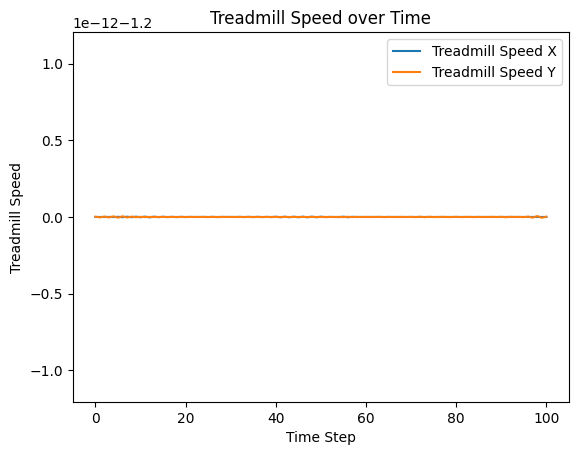

In [ ]:
plt.plot(states.gc_model[:,0], label='Treadmill Speed X')
plt.plot(states.gc_model[:,1], label='Treadmill Speed Y')
plt.xlabel('Time Step')
plt.ylabel('Treadmill Speed')
plt.title('Treadmill Speed over Time')
plt.legend()

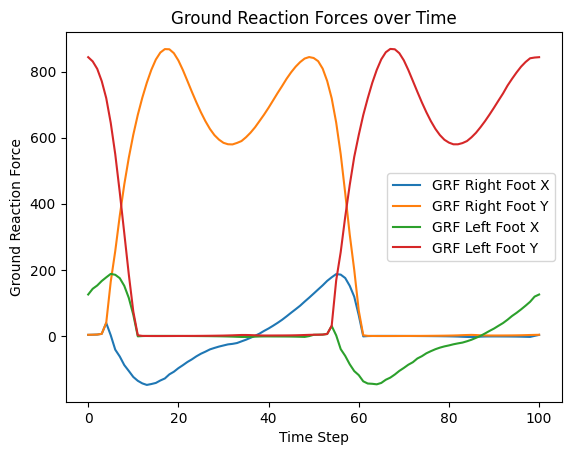

In [ ]:
grf_x_r = states.model[:, m.state_vector.index('f_foot_r_x')]
grf_y_r = states.model[:, m.state_vector.index('f_foot_r_y')]
grf_x_l = states.model[:, m.state_vector.index('f_foot_l_x')]
grf_y_l = states.model[:, m.state_vector.index('f_foot_l_y')]
plt.figure()
plt.plot(grf_x_r, label='GRF Right Foot X')
plt.plot(grf_y_r, label='GRF Right Foot Y')
plt.plot(grf_x_l, label='GRF Left Foot X')
plt.plot(grf_y_l, label='GRF Left Foot Y')
plt.xlabel('Time Step')
plt.ylabel('Ground Reaction Force')
plt.title('Ground Reaction Forces over Time')
plt.legend()

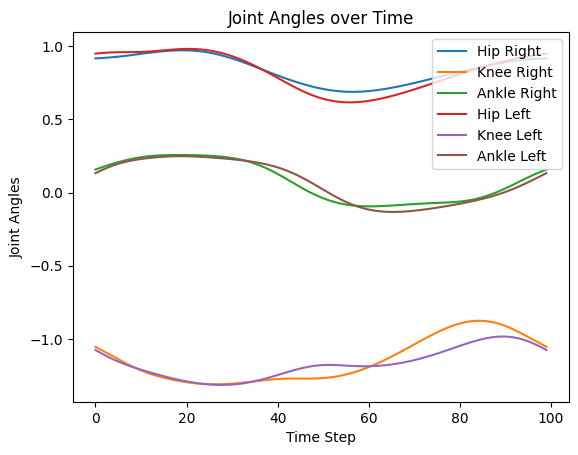

In [ ]:
plt.plot(states.model[:, m.state_vector.index('q_hip_r')], label='Hip Right')
plt.plot(states.model[:, m.state_vector.index('q_knee_r')], label='Knee Right')
plt.plot(states.model[:, m.state_vector.index('q_ankle_r')], label='Ankle Right')
plt.plot(states.model[:, m.state_vector.index('q_hip_l')], label='Hip Left')
plt.plot(states.model[:, m.state_vector.index('q_knee_l')], label='Knee Left')
plt.plot(states.model[:, m.state_vector.index('q_ankle_l')], label='Ankle Left')
plt.xlabel('Time Step')
plt.ylabel('Joint Angles')
plt.title('Joint Angles over Time')
plt.legend()